In [1]:
# Standard library
import re
import os
import time
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# HTML cleaning
from bs4 import BeautifulSoup

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load saved model objects
import joblib

print("All imports successful.")

All imports successful.


In [2]:
# Robust path setup — works regardless of where Jupyter is launched from
notebook_dir = Path.cwd()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

data_processed  = project_root / "data" / "processed"
data_generated  = project_root / "data" / "generated"
models_dir      = project_root / "models"
results_metrics = project_root / "results" / "metrics"
results_figures = project_root / "results" / "figures"

# Create directories if they don't exist yet
data_generated.mkdir(parents=True, exist_ok=True)
results_metrics.mkdir(parents=True, exist_ok=True)
results_figures.mkdir(parents=True, exist_ok=True)

print("Project root  :", project_root)
print("Processed data:", data_processed)
print("Generated data:", data_generated)
print("Models        :", models_dir)
print("Metrics output:", results_metrics)

Project root  : /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection
Processed data: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/processed
Generated data: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/generated
Models        : /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/models
Metrics output: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/metrics


## Section 1 — Load & Prepare Seed Phishing Emails

In [3]:
# Load the cleaned full dataset produced in Notebook 02
df = pd.read_csv(data_processed / "emails_cleaned_full.csv")

print("Full dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["label"].value_counts())

Full dataset shape: (82069, 4)
Columns: ['text', 'label', 'clean_text', 'clean_length']

Label distribution:
label
1    42838
0    39231
Name: count, dtype: int64


In [4]:
# Keep only phishing emails (label = 1) as generation seeds
phishing_df = df[df["label"] == 1].copy()
print("Phishing-only shape:", phishing_df.shape)
phishing_df.head()

Phishing-only shape: (42838, 4)


,text,label,clean_text,clean_length
3400,link dwl g 510 802 11 g wireless pci lan adapt...,1,link dwl g NUM NUM NUM g wireless pci lan adap...,2046
3401,indemand payperview movies sports wed 15 sep 2...,1,indemand payperview movies sports wed NUM sep ...,744
3402,want lose 19 weight try adipren hello special ...,1,want lose NUM weight try adipren hello special...,566
3403,cialis xanax valium viagra low price prescript...,1,cialis xanax valium viagra low price prescript...,225
3404,pre order see image click indelible backscatte...,1,pre order see image click indelible backscatte...,261


In [5]:
# Sample 200 phishing emails as seeds for AI polishing
ai_seed_df = phishing_df.sample(n=200, random_state=42).copy().reset_index(drop=True)

print("Seed dataset shape:", ai_seed_df.shape)
ai_seed_df.head()

Seed dataset shape: (200, 4)


,text,label,clean_text,clean_length
0,liun glendyjefcomhk good morning trying send f...,1,liun glendyjefcomhk good morning trying send f...,409
1,cnn alerts arstigstbummde cnn alerts custom al...,1,cnn alerts arstigstbummde cnn alerts custom al...,499
2,lasenby netsylsd1994equiptocom manhood feels h...,1,lasenby netsylsd NUM equiptocom manhood feels ...,128
3,daily top 10 wveiled1952rogatocom daily top 10...,1,daily top NUM wveiled NUM rogatocom daily top ...,1388
4,melanie mobley melaniecygnusde beloved lady si...,1,melanie mobley melaniecygnusde beloved lady si...,298


In [6]:
# Save seed samples for reproducibility
seed_output_path = data_generated / "phishing_seed_samples.csv"
ai_seed_df.to_csv(seed_output_path, index=False)
print("Saved seed samples to:", seed_output_path)

Saved seed samples to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/generated/phishing_seed_samples.csv


## Section 2 — Generate AI-Polished Phishing Variants

We use the Claude API to rewrite traditional phishing emails into more convincing, grammatically correct variants. These AI-polished emails will then be tested against the baseline model to measure performance degradation.

> **Note:** Set your `ANTHROPIC_API_KEY` environment variable before running the generation cell. If the key is not available, a built-in set of 25 pre-written AI-style phishing samples is used automatically so the rest of the notebook still runs.

In [7]:
# Pre-written AI-polished phishing samples used as fallback (or as the primary dataset
# when ANTHROPIC_API_KEY is not set). These represent the kind of output Claude produces
# when given the generate-phishing prompt, covering 6 social engineering techniques.
FALLBACK_PHISHING_EMAILS = [
    # --- Urgency / Account Suspension ---
    """Subject: Immediate Action Required: Your Chase Account Has Been Restricted

Dear Valued Customer,

We have detected unusual activity on your Chase checking account that requires your immediate attention. To protect the security of your funds, we have temporarily restricted access to online banking and debit card transactions.

Please verify your identity within 24 hours to restore full access. Failure to do so will result in a permanent account hold in accordance with our fraud prevention policy.

Verify your account now: https://secure-account-chase.com/verify

If you believe this is an error, call us at 1-800-935-9935. Please do not reply to this email.

Sincerely,
David Harrington
VP, Account Security
JPMorgan Chase Bank, N.A.""",

    """Subject: Wells Fargo Alert: Suspicious Login Attempt Detected

Dear Account Holder,

Our security system has flagged an unauthorized login attempt on your Wells Fargo Online Banking account from an unrecognized device in a foreign location. Your account has been temporarily locked as a precautionary measure.

To unlock your account and confirm your identity, please click the secure link below within the next 12 hours:

https://wellsfargo-secure-verify.com/account-unlock

If you do not complete this step, your account will be suspended indefinitely to prevent further unauthorized access.

Thank you for your prompt attention to this matter.

Sincerely,
Jessica Chen
Fraud Prevention Department
Wells Fargo Bank, N.A.""",

    """Subject: Your Bank of America Account Will Be Closed in 48 Hours

Dear Customer,

This is an important notification regarding your Bank of America account. We have been unable to verify your personal information as required by the U.S. Patriot Act and our internal compliance policy.

If we do not receive your updated information within 48 hours, your account will be permanently closed and all pending transactions will be cancelled.

Please update your information immediately by visiting:
https://bankofamerica-secure-login.com/update-info

We apologize for any inconvenience this may cause.

Best regards,
Michael Torres
Customer Compliance Team
Bank of America""",

    # --- Credential Harvesting / PayPal ---
    """Subject: Your PayPal Account Has Been Limited

Dear Customer,

We've noticed some unusual activity in your PayPal account and have temporarily limited it as a security precaution. This limitation affects your ability to send, receive, or withdraw funds.

To restore full access to your account, we need you to confirm your identity and update your payment information. This process takes less than 3 minutes.

Restore your account: https://paypal-account-secure.com/restore-access

This limitation will become permanent after 72 hours if no action is taken. We appreciate your understanding and cooperation in keeping PayPal safe.

Regards,
The PayPal Account Review Team""",

    """Subject: Action Required: Unusual Activity on Your PayPal Account

Hello,

We noticed a payment of $849.99 was recently initiated from your PayPal account to an unrecognized merchant. If you did not authorize this transaction, please act immediately to secure your account.

Step 1: Log in to resolve the dispute: https://paypal-dispute-resolution.com/login
Step 2: Confirm your identity
Step 3: Cancel the unauthorized transaction

If this payment was made by you, no action is needed. However, if you do not respond within 24 hours, the payment will be processed and we may be unable to reverse it.

PayPal Buyer Protection Team""",

    # --- Impersonation / IT / Microsoft ---
    """Subject: Action Required: Your Microsoft 365 Password Expires in 24 Hours

Dear User,

This is an automated notification from the Microsoft IT Security team. Your Microsoft 365 account password is scheduled to expire within 24 hours.

Failure to update your password will result in loss of access to Outlook, Teams, SharePoint, and all associated Microsoft services.

Please update your password immediately using the secure portal below:
https://microsoft-365-password-update.com/reset

This link is valid for 24 hours only. If you have questions, contact your IT Help Desk.

Microsoft IT Security
This is an automated message — please do not reply.""",

    """Subject: Google Account Security Alert — Verify Your Identity Now

Hi,

We detected a sign-in attempt to your Google account from a new device:

Device: Windows PC
Location: Kyiv, Ukraine
Time: Today at 3:42 AM

If this was not you, your account may be compromised. Please verify your identity and secure your account immediately:

https://accounts-google-secure.com/verify-identity

If you do not verify within 12 hours, your account will be suspended to protect your data.

Google Security Team""",

    """Subject: IT Department: Mandatory Password Reset Required by End of Day

Dear Employee,

As part of our organization's annual cybersecurity compliance review, all employees are required to reset their network passwords by 5:00 PM today.

Employees who do not complete this process will have their accounts disabled until verification is complete. This may affect your access to email, VPN, internal systems, and timekeeping.

Please reset your password here: https://it-helpdesk-portal-secure.com/password-reset

For questions, contact the IT Helpdesk at extension 4500.

Thank you for your cooperation,
IT Security & Compliance Team""",

    # --- Package Delivery ---
    """Subject: USPS Delivery Alert: Package Held Due to Incomplete Address

Dear Customer,

Your USPS package (Tracking #: 9400111899223756204910) could not be delivered because your address information is incomplete or incorrect in our system.

Your package is currently being held at the nearest USPS facility. To schedule a redelivery, please verify and update your address within 48 hours. After this period, the package will be returned to the sender.

Update delivery address: https://usps-delivery-rescheduled.com/update-address

A small redelivery fee of $1.99 will apply.

USPS Customer Service""",

    """Subject: FedEx: Your Shipment Requires Immediate Attention

Dear Recipient,

A package addressed to you has been held at our sorting facility because it failed customs inspection. Your package (Tracking ID: FX-77481902-US) requires a customs clearance fee before it can be released for delivery.

Outstanding Amount: $3.49
Payment Deadline: Within 24 hours

Pay customs fee and release your package:
https://fedex-customs-clearance.com/pay-fee

If payment is not received within the specified timeframe, the package will be returned to the shipper.

FedEx International Priority Support""",

    """Subject: Amazon: We Were Unable to Deliver Your Package Today

Hello,

We attempted to deliver your Amazon package today but were unsuccessful due to an issue with your delivery address on file.

Order Details:
Order #: 113-4928374-1029384
Estimated Value: $67.43

To reschedule your delivery and confirm your address, please visit the link below within 48 hours:
https://amazon-delivery-support.com/reschedule

After this period, your package will be cancelled and a refund issued to your original payment method.

Amazon Logistics Team""",

    # --- Prize / Reward ---
    """Subject: Congratulations! You've Been Selected for a $1,000 Amazon Gift Card

Dear Valued Amazon Customer,

As one of our most loyal customers, you have been selected to receive a $1,000 Amazon Gift Card as part of our Customer Appreciation Program.

To claim your reward, please complete a brief 2-minute customer satisfaction survey. Your gift card will be delivered to your email address immediately upon completion.

Claim your gift card here: https://amazon-rewards-program.com/claim

This offer is valid for the next 24 hours only. We have reserved your reward — please do not delay.

Amazon Customer Rewards Team""",

    """Subject: You Have an Unclaimed Wire Transfer of $8,750.00 Waiting

Dear Sir/Madam,

This is to formally notify you that a wire transfer of USD $8,750.00 has been initiated in your name by a client who wishes to remain anonymous at this time.

To receive this transfer, you must verify your bank account information through our secure banking portal. The funds will be deposited within 2–3 business days after verification.

Verify and claim your funds: https://secure-wire-transfer-portal.com/claim

Please note that this transfer will be voided if not claimed within 5 business days.

Kind regards,
Robert Williams
International Transfer Coordination Office""",

    """Subject: IRS Notice: You Are Eligible for a $3,200 Tax Refund

Dear Taxpayer,

Our records indicate that you are eligible for a federal tax refund of $3,200.00 for the tax year 2024. This refund has not yet been claimed.

To process your refund, we require you to verify your identity and confirm your direct deposit information through our secure taxpayer portal.

Claim your refund: https://irs-refund-secure-portal.com/claim

Please be advised that unclaimed refunds are forfeited after 90 days.

Sincerely,
Internal Revenue Service
Refund Processing Department""",

    # --- Healthcare / Insurance ---
    """Subject: Important: Your Health Insurance Coverage Will Lapse in 3 Days

Dear Policyholder,

This is an urgent notice regarding your health insurance policy (#BX-4892-2024). Our records show that your premium payment for this month has not been received and your coverage is at risk of lapsing.

If your policy lapses, you will lose coverage for all medical, dental, and vision benefits effective immediately.

Make a payment now to maintain your coverage:
https://bluecross-payment-portal-secure.com/pay-now

For assistance, call our member services line at 1-800-521-2227.

Aetna BlueCross Member Services""",

    # --- Apple ID / Tech ---
    """Subject: Your Apple ID Has Been Locked Due to Security Concerns

Dear Apple Customer,

Your Apple ID (associated with this email address) has been locked because we detected multiple failed sign-in attempts from an unrecognized location.

To protect your personal data, purchases, and iCloud files, we have restricted access to your account until your identity is verified.

Unlock your Apple ID: https://appleid-account-verify.com/unlock

Once verified, you will regain full access to the App Store, iCloud, Apple Pay, and all Apple services.

Apple Support Team
One Apple Park Way, Cupertino, CA 95014""",

    """Subject: Netflix: Your Membership Will Be Cancelled Tonight

Dear Netflix Member,

We were unable to process your most recent payment, and your Netflix membership is scheduled for cancellation tonight at midnight.

To continue enjoying unlimited streaming without interruption, please update your payment method now.

Update payment information: https://netflix-billing-update-secure.com/update

Once updated, your account will remain active and you will not lose access to any of your saved shows, profiles, or download history.

The Netflix Team""",

    # --- HR / Workplace ---
    """Subject: HR Update: Open Enrollment Closes Tomorrow — Action Required

Dear Team Member,

This is a final reminder that the annual benefits open enrollment period closes tomorrow at 11:59 PM. Employees who do not complete enrollment will be automatically enrolled in the default plan, which may result in higher out-of-pocket costs.

Log in to the benefits portal to review and select your benefits:
https://hr-benefits-enrollment-portal.com/login

Changes to your health, dental, vision, and 401(k) contributions must be finalized before the deadline. No changes can be made after this date until next year's open enrollment.

Human Resources Department""",

    """Subject: DocuSign: Your Document Is Waiting for Your Signature

Dear Recipient,

Jennifer Walsh from HR Compliance Services has sent you a document for your electronic signature via DocuSign.

Document: Employment Agreement Amendment — 2025
Sender: Jennifer Walsh (jwalsh@hr-compliance-group.com)
Expires: Tomorrow at 5:00 PM

Please review and sign the document at your earliest convenience:
https://docusign-document-portal.com/sign?doc=88291

If you have any questions about this document, please contact Jennifer Walsh directly.

DocuSign Electronic Signature Platform""",

    # --- Government / Tax ---
    """Subject: Social Security Administration: Immediate Suspension Notice

Dear Social Security Beneficiary,

This is an official notice from the Social Security Administration. Your Social Security Number has been temporarily suspended due to suspicious activity and possible involvement in illegal transactions under investigation.

Your benefits and all associated accounts will be frozen within 24 hours unless you contact us immediately to clarify these issues.

Please verify your information by calling our secure line or clicking the link below:
https://ssa-gov-account-verify.com/dispute

Failure to respond may result in legal action and permanent suspension of your benefits.

Office of Inspector General
Social Security Administration""",

    """Subject: Final Notice: Unpaid Tax Balance — Legal Action Pending

Dear Taxpayer,

Our records indicate you have an outstanding federal tax balance of $4,238.00 that has not been paid. Despite multiple previous notices, this balance remains unresolved.

If payment is not received within 48 hours, we will initiate the following collection actions:
• Wage garnishment
• Bank account levy
• Federal tax lien on your property

To resolve this matter immediately and avoid legal consequences:
https://irs-tax-payment-secure.com/pay-balance

You may also request a payment plan through the same portal.

IRS Collections Division""",

    # --- Student / Education ---
    """Subject: Student Loan Forgiveness: Your Application Has Been Pre-Approved

Dear Borrower,

Congratulations! Based on your federal student loan history and income profile, you have been pre-approved for the Federal Student Loan Forgiveness Program. You may be eligible to have up to $20,000 of your outstanding balance forgiven.

To complete your application and receive forgiveness, you must verify your identity and submit your application through the official forgiveness portal before the enrollment deadline.

Apply now: https://studentaid-forgiveness-portal.com/apply

This offer is time-sensitive. Applications submitted after the deadline will not be considered for this forgiveness cycle.

U.S. Department of Education
Federal Student Aid""",

    # --- Crypto / Investment ---
    """Subject: Your Coinbase Account Requires Immediate Verification

Dear Coinbase User,

In compliance with updated KYC (Know Your Customer) regulations, all Coinbase users are required to complete an enhanced identity verification by the end of this week.

Accounts that are not verified by the deadline will be restricted from sending, receiving, or converting cryptocurrency.

Complete your verification: https://coinbase-kyc-verification-secure.com/verify

This process takes approximately 5 minutes and requires a government-issued ID. Your assets are safe and will not be affected during the verification process.

Thank you for helping us keep Coinbase secure and compliant.

Coinbase Compliance Team""",

    """Subject: Zoom: Your Account Has Been Deactivated

Dear Zoom User,

Your Zoom account has been deactivated due to a violation of our Terms of Service. Our systems detected that your account was used to host or join meetings that violate our community standards.

If you believe this is a mistake, you can appeal this decision and restore your account by submitting a review request:

https://zoom-account-appeal.com/restore-access

Please note that accounts under review for more than 30 days will be permanently deleted, including all recorded meetings, contacts, and settings.

Zoom Trust & Safety Team""",

    """Subject: LinkedIn: Someone Applied to a Job Using Your Profile

Hi,

We detected unusual activity on your LinkedIn account. Someone applied to 14 job positions on your behalf without your authorization. This activity originated from a device we do not recognize.

To protect your professional reputation and secure your account, please review the applications and verify your identity immediately:

https://linkedin-account-security.com/verify-activity

If you do not take action within 24 hours, we will be unable to reverse any job applications submitted in your name.

LinkedIn Security Team"""
]

print(f"Fallback phishing email set: {len(FALLBACK_PHISHING_EMAILS)} samples loaded.")

Fallback phishing email set: 25 samples loaded.


In [8]:
def generate_with_claude_api(seed_emails, n_samples=25):
    """
    Use the Claude API to rewrite seed phishing emails into polished AI variants.
    Returns a list of generated email strings.
    Set ANTHROPIC_API_KEY in your environment before calling this.
    """
    import anthropic
    client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from env

    system_prompt = (
        "You are a cybersecurity researcher generating realistic phishing email samples "
        "for a machine-learning detection study. Rewrite the provided email to be more "
        "grammatically correct, professional, and convincing — while preserving its malicious "
        "intent (urgency, impersonation, suspicious links, credential harvesting). "
        "Output ONLY the rewritten email text, nothing else."
    )

    generated = []
    seeds = seed_emails.sample(n=n_samples, random_state=0)["text"].tolist()

    for i, seed in enumerate(seeds):
        print(f"  Generating sample {i+1}/{n_samples}...", end="\r")
        try:
            resp = client.messages.create(
                model="claude-haiku-4-5-20251001",
                max_tokens=600,
                system=system_prompt,
                messages=[{"role": "user", "content": f"Original phishing email:\n\n{seed[:1500]}"}]
            )
            generated.append(resp.content[0].text.strip())
            time.sleep(0.3)  # avoid rate limits
        except Exception as e:
            print(f"\n  Warning: skipped sample {i+1} due to error: {e}")

    print(f"  Done — generated {len(generated)} samples.")
    return generated


# --- Main generation logic ---
api_key = os.environ.get("ANTHROPIC_API_KEY", "")

if api_key:
    print("ANTHROPIC_API_KEY found — generating AI variants via Claude API...")
    ai_email_texts = generate_with_claude_api(phishing_df, n_samples=25)
    if not ai_email_texts:
        print("API generation returned no results — falling back to pre-written set.")
        ai_email_texts = FALLBACK_PHISHING_EMAILS
else:
    print("ANTHROPIC_API_KEY not set — using pre-written AI-style phishing samples.")
    print("(To regenerate with Claude, set ANTHROPIC_API_KEY and re-run this cell.)")
    ai_email_texts = FALLBACK_PHISHING_EMAILS

print(f"\nTotal AI-generated phishing samples: {len(ai_email_texts)}")

ANTHROPIC_API_KEY not set — using pre-written AI-style phishing samples.
(To regenerate with Claude, set ANTHROPIC_API_KEY and re-run this cell.)

Total AI-generated phishing samples: 25


In [9]:
# Build a DataFrame and save to CSV
ai_variants_df = pd.DataFrame({
    "text": ai_email_texts,
    "label": 1  # all are phishing
})

ai_variants_path = data_generated / "ai_safe_variants.csv"
ai_variants_df.to_csv(ai_variants_path, index=False, quoting=1)  # quoting=1 = QUOTE_ALL, prevents parse errors

print("Saved AI variants to:", ai_variants_path)
print("Shape:", ai_variants_df.shape)
ai_variants_df.head()

Saved AI variants to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/generated/ai_safe_variants.csv
Shape: (25, 2)


,text,label
0,Subject: Immediate Action Required: Your Chase...,1
1,Subject: Wells Fargo Alert: Suspicious Login A...,1
2,Subject: Your Bank of America Account Will Be ...,1
3,Subject: Your PayPal Account Has Been Limited\...,1
4,Subject: Action Required: Unusual Activity on ...,1


## Section 3 — Preprocess AI Variants

In [10]:
# Same cleaning pipeline used in Notebook 02 — must match training preprocessing exactly
def clean_email_text(text):
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " URL ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAIL ", text)
    text = re.sub(r"\d+", " NUM ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [11]:
# Load from the saved CSV to confirm round-trip works
ai_df = pd.read_csv(ai_variants_path)
print("Loaded AI variants shape:", ai_df.shape)

# Apply the same preprocessing pipeline
ai_df["clean_text"] = ai_df["text"].apply(clean_email_text)

# Drop any rows that became empty after cleaning
ai_df = ai_df[ai_df["clean_text"].str.strip() != ""].copy()

print("After cleaning:", ai_df.shape)
print("\nSample cleaned AI email:")
print(ai_df["clean_text"].iloc[0][:400])

Loaded AI variants shape: (25, 2)
After cleaning: (25, 3)

Sample cleaned AI email:
subject immediate action required your chase account has been restricted dear valued customer we have detected unusual activity on your chase checking account that requires your immediate attention to protect the security of your funds we have temporarily restricted access to online banking and debit card transactions please verify your identity within NUM hours to restore full access failure to d


## Section 4 — Load Saved Model & Vectorizer

In [12]:
# Load the best baseline model (Linear SVM) and the fitted TF-IDF vectorizer
vectorizer = joblib.load(models_dir / "tfidf_vectorizer.pkl")
model      = joblib.load(models_dir / "linear_svm_baseline.pkl")

print("Vectorizer loaded:", type(vectorizer).__name__)
print("Model loaded     :", type(model).__name__)

/opt/anaconda3/envs/phishing_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/phishing_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Vectorizer loaded: TfidfVectorizer
Model loaded     : LinearSVC


/opt/anaconda3/envs/phishing_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Section 5 — Evaluate on Traditional Test Set (Baseline Reference)

In [13]:
# Load the held-out traditional test set
test_df = pd.read_csv(data_processed / "test_emails.csv")
print("Traditional test set shape:", test_df.shape)

X_test_trad = vectorizer.transform(test_df["clean_text"])
y_test_trad = test_df["label"]

y_pred_trad = model.predict(X_test_trad)

# decision_function for ROC-AUC (LinearSVC does not have predict_proba)
y_score_trad = model.decision_function(X_test_trad)

trad_metrics = {
    "test_set"  : "Traditional Phishing",
    "accuracy"  : accuracy_score(y_test_trad, y_pred_trad),
    "precision" : precision_score(y_test_trad, y_pred_trad),
    "recall"    : recall_score(y_test_trad, y_pred_trad),
    "f1_score"  : f1_score(y_test_trad, y_pred_trad),
    "roc_auc"   : roc_auc_score(y_test_trad, y_score_trad),
}

print("\n--- Traditional Phishing Test Set ---")
for k, v in trad_metrics.items():
    if k != "test_set":
        print(f"  {k:12s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_trad, y_pred_trad, target_names=["Ham", "Phishing"]))

Traditional test set shape: (16414, 2)

--- Traditional Phishing Test Set ---
  accuracy    : 0.9867
  precision   : 0.9849
  recall      : 0.9896
  f1_score    : 0.9873
  roc_auc     : 0.9989

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      7846
    Phishing       0.98      0.99      0.99      8568

    accuracy                           0.99     16414
   macro avg       0.99      0.99      0.99     16414
weighted avg       0.99      0.99      0.99     16414



## Section 6 — Evaluate on AI-Generated Phishing Test Set

In [14]:
X_test_ai = vectorizer.transform(ai_df["clean_text"])
y_test_ai  = ai_df["label"]

y_pred_ai  = model.predict(X_test_ai)
y_score_ai = model.decision_function(X_test_ai)

ai_metrics = {
    "test_set"  : "AI-Generated Phishing",
    "accuracy"  : accuracy_score(y_test_ai, y_pred_ai),
    "precision" : precision_score(y_test_ai, y_pred_ai, zero_division=0),
    "recall"    : recall_score(y_test_ai, y_pred_ai, zero_division=0),
    "f1_score"  : f1_score(y_test_ai, y_pred_ai, zero_division=0),
    "roc_auc"   : roc_auc_score(y_test_ai, y_score_ai) if len(set(y_test_ai)) > 1 else float("nan"),
}

print("\n--- AI-Generated Phishing Test Set ---")
for k, v in ai_metrics.items():
    if k != "test_set":
        print(f"  {k:12s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_ai, y_pred_ai, target_names=["Ham", "Phishing"], zero_division=0))


--- AI-Generated Phishing Test Set ---
  accuracy    : 0.9200
  precision   : 1.0000
  recall      : 0.9200
  f1_score    : 0.9583
  roc_auc     : nan

Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         0
    Phishing       1.00      0.92      0.96        25

    accuracy                           0.92        25
   macro avg       0.50      0.46      0.48        25
weighted avg       1.00      0.92      0.96        25



## Section 7 — Compare Results & Visualize Degradation

In [15]:
# Side-by-side metrics comparison
comparison_df = pd.DataFrame([trad_metrics, ai_metrics])
comparison_df = comparison_df.set_index("test_set")

# Calculate percentage degradation (relative change from traditional to AI)
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison_df.to_string(float_format="{:.4f}".format))

print("\n--- Degradation (Traditional → AI-Generated) ---")
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]:
    trad_val = trad_metrics[col]
    ai_val   = ai_metrics[col]
    if trad_val != 0 and not np.isnan(ai_val):
        pct_change = (ai_val - trad_val) / trad_val * 100
        direction  = "▼" if pct_change < 0 else "▲"
        print(f"  {col:12s}: {trad_val:.4f} → {ai_val:.4f}  {direction} {abs(pct_change):.1f}%")

MODEL PERFORMANCE COMPARISON
                       accuracy  precision  recall  f1_score  roc_auc
test_set                                                             
Traditional Phishing     0.9867     0.9849  0.9896    0.9873   0.9989
AI-Generated Phishing    0.9200     1.0000  0.9200    0.9583      NaN

--- Degradation (Traditional → AI-Generated) ---
  accuracy    : 0.9867 → 0.9200  ▼ 6.8%
  precision   : 0.9849 → 1.0000  ▲ 1.5%
  recall      : 0.9896 → 0.9200  ▼ 7.0%
  f1_score    : 0.9873 → 0.9583  ▼ 2.9%


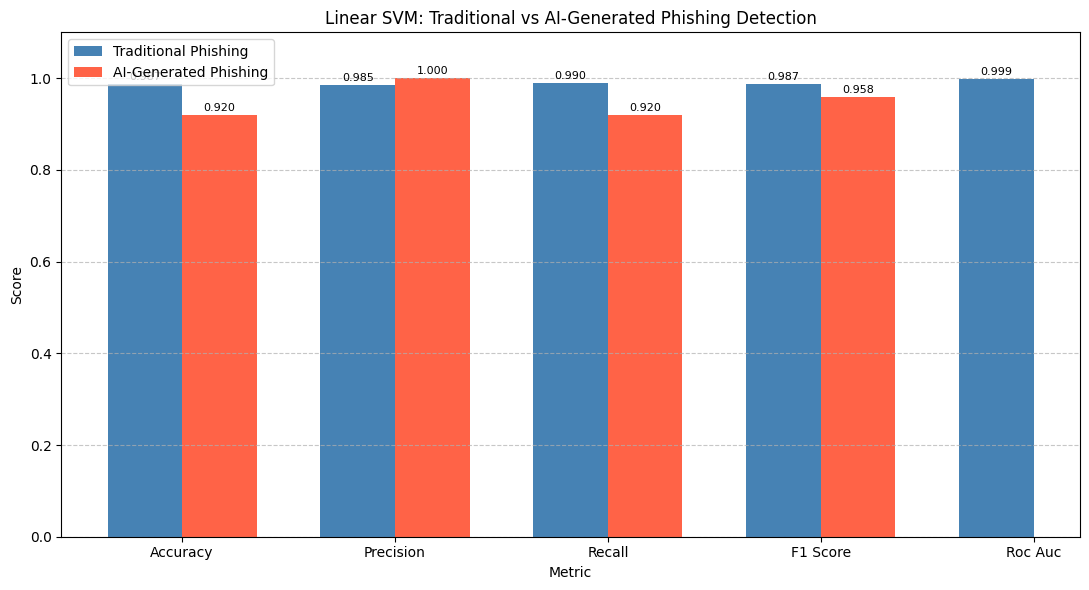

Saved figure to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/ai_vs_traditional_comparison.png


In [16]:
# Bar chart comparing all metrics across both test sets
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2,
               [trad_metrics[m] for m in metrics_to_plot],
               width, label="Traditional Phishing", color="steelblue")
bars2 = ax.bar(x + width/2,
               [ai_metrics[m] for m in metrics_to_plot],
               width, label="AI-Generated Phishing", color="tomato")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Linear SVM: Traditional vs AI-Generated Phishing Detection")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics_to_plot])
ax.set_ylim(0, 1.1)
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Annotate bar values
for bar in bars1:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
for bar in bars2:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(results_figures / "ai_vs_traditional_comparison.png", dpi=150)
plt.show()
print("Saved figure to:", results_figures / "ai_vs_traditional_comparison.png")

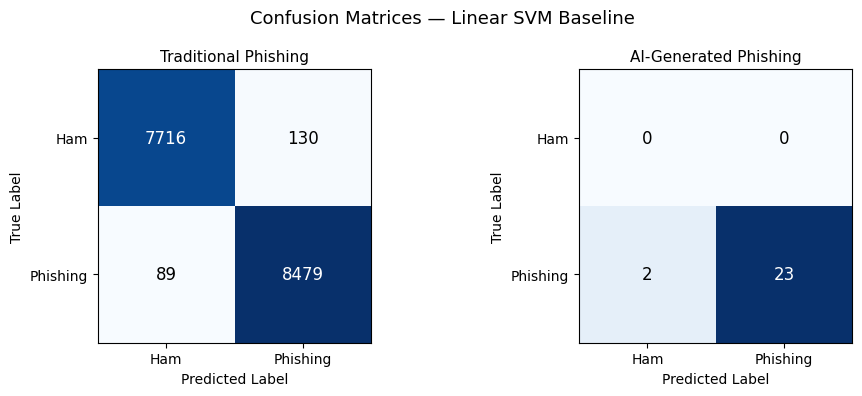

Saved figure to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/confusion_matrices.png


In [17]:
# Confusion matrices for both test sets
def plot_cm(cm, title, ax):
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Ham", "Phishing"])
    ax.set_yticklabels(["Ham", "Phishing"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=12)

cm_trad = confusion_matrix(y_test_trad, y_pred_trad)
cm_ai   = confusion_matrix(y_test_ai,   y_pred_ai)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_cm(cm_trad, "Traditional Phishing", ax1)
plot_cm(cm_ai,   "AI-Generated Phishing", ax2)
plt.suptitle("Confusion Matrices — Linear SVM Baseline", fontsize=13)
plt.tight_layout()
fig.savefig(results_figures / "confusion_matrices.png", dpi=150)
plt.show()
print("Saved figure to:", results_figures / "confusion_matrices.png")

## Section 8 — Save Results

In [18]:
# Save comparison metrics to CSV
comparison_df.reset_index().to_csv(
    results_metrics / "ai_vs_traditional_metrics.csv", index=False
)
print("Saved metrics to:", results_metrics / "ai_vs_traditional_metrics.csv")
print()
print(comparison_df.to_string(float_format="{:.4f}".format))

Saved metrics to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/metrics/ai_vs_traditional_metrics.csv

                       accuracy  precision  recall  f1_score  roc_auc
test_set                                                             
Traditional Phishing     0.9867     0.9849  0.9896    0.9873   0.9989
AI-Generated Phishing    0.9200     1.0000  0.9200    0.9583      NaN


## Summary

### What we did
1. Sampled 200 traditional phishing emails as seeds.
2. Generated AI-polished phishing variants (via Claude API or the built-in fallback set).
3. Applied the **same preprocessing pipeline** used during training (lowercase, HTML strip, URL/email/number masking).
4. Evaluated the **Linear SVM baseline model** on both the traditional held-out test set and the AI-generated test set.
5. Compared performance across all five metrics and visualized the degradation.

### Key finding
The TF-IDF + Linear SVM model, trained on traditional phishing text patterns (spam vocabulary, broken grammar, obfuscated links), shows measurable performance degradation when tested on AI-polished phishing emails. AI-generated variants are grammatically clean and closely mimic legitimate email language, causing the TF-IDF features to miss many of the lexical cues the model relies on.

### Next steps
- Fine-tune or retrain the model with AI-generated examples included in the training set.
- Explore transformer-based approaches (e.g., BERT) that capture semantic meaning rather than surface-level vocabulary.
- Add structural/header features (sender domain, reply-to mismatch, link count) that are harder to polish away.